<a href="https://colab.research.google.com/github/deepakri201/SR_for_NLST_Sybil/blob/main/read_sr_demo/NLST_Sybil_demo_read_SR_and_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLST Sybil demo notebook - read DICOM Structured Report and plot the bounding box

In this notebook, we demonstrate how to:
- Read a single DICOM Structured Report (SR) that holds the bounding box annotations for a patient in the National Lung Screening Trial (NLST) collection.
- Plot the bounding box overlaid on the CT image

Note:
- Currently the sample SR is read from a private bucket. Later, it will be read from the IDC bucket
- Could also include demo where we query IDC data to get SR data and then plot the bounding box

Deepa Krishnaswamy

Brigham and Women's Hospital

September 2025

In [ ]:
location = 'us-central1'
bucket_sr_directory = "gs://sr_nlst_sybil"

# Parameterization

In [ ]:
#@title Enter your Project ID here
# initialize this variable with your Google Cloud Project ID!
project_name = "idc-external-018" #@param {type:"string"}

import os
os.environ["GCP_PROJECT_ID"] = project_name

!gcloud config set project $project_name

from google.colab import auth
auth.authenticate_user()

Updated property [core/project].


# Environment Setup

In [ ]:
!pip install idc-index

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.2 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing installation: duckdb 1.3.2
    Uninstalling duckdb-1.3.2:
      Successfully uninstalled duckdb-1.3.2


In [ ]:
import os
import sys
import time

import numpy as np
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

import json
from pathlib import Path

In [ ]:
from idc_index import IDCClient

idc_client = IDCClient.client()

In [ ]:
!git clone https://github.com/imagingdatacommons/highdicom ~/highdicom

Cloning into '/root/highdicom'...
remote: Enumerating objects: 8326, done.
remote: Counting objects: 100% (1966/1966), done.
remote: Compressing objects: 100% (289/289), done.
remote: Total 8326 (delta 1829), reused 1677 (delta 1677), pack-reused 6360 (from 2)
Receiving objects: 100% (8326/8326), 6.82 MiB | 9.52 MiB/s, done.
Resolving deltas: 100% (5511/5511), done.


In [ ]:
!pip install ~/highdicom

Processing /root/highdicom
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.7 MB/s eta 0:00:00
  Created wheel for highdicom: filename=highdicom-0.26.1-py3-none-any.whl size=1106466 sha256=37e09abd52a86655298642e5866f290eb6965fd6b5506b6559af80c4d8f0be90
  Stored in directory: /tmp/pip-ephem-wheel-cache-4kiu4msr/wheels/e1/2a/ca/e605fe591961d04f0a82d0ca4d8593aaeeba598f4a9c806a09
Successfully built highdicom


In [ ]:
import pydicom
from pydicom.uid import generate_uid
from pydicom.filereader import dcmread
from pydicom.sr.codedict import codes

In [ ]:
from highdicom.sr.content import (
    FindingSite,
    ImageRegion,
    ImageRegion3D,
    SourceImageForRegion
)

from highdicom.sr.enum import GraphicTypeValues3D
from highdicom.sr.enum import GraphicTypeValues
from highdicom.sr.sop import Comprehensive3DSR, ComprehensiveSR
from highdicom.sr.templates import (
    DeviceObserverIdentifyingAttributes,
    Measurement,
    MeasurementProperties,
    MeasurementReport,
    ObservationContext,
    ObserverContext,
    PersonObserverIdentifyingAttributes,
    PlanarROIMeasurementsAndQualitativeEvaluations,
    RelationshipTypeValues,
    TrackingIdentifier,
    QualitativeEvaluation
)
# from highdicom.sr.value_types import (
#     CodedConcept,
#     CodeContentItem,
# )
# why from highdicom.sr.value_types for CodedConcept? Should be highdicom.sr.CodedConcept
from highdicom.sr import CodedConcept

from highdicom.sr import ImageLibrary
from highdicom.sr import ImageLibraryEntryDescriptors
from highdicom.sr.value_types import Code
from highdicom.sr.value_types import ContentItem
from highdicom.sr import PixelOriginInterpretationValues

import logging
logger = logging.getLogger("highdicom.sr.sop")
logger.setLevel(logging.INFO)

In [ ]:
import highdicom as hd
hd.__version__

'0.26.1'

In [ ]:
pydicom.__version__

'3.0.1'

# 1. Read and parse the DICOM SR

In [ ]:
sr_bucket_filename = os.path.join(bucket_sr_directory, "129695", "1.2.840.113654.2.55.15984899811178273278176379087873074846.dcm")
sr_filename = "/content/sr.dcm"
!gsutil cp $sr_bucket_filename $sr_filename

sr = hd.sr.srread(sr_filename)

Copying gs://sr_nlst_sybil/129695/1.2.840.113654.2.55.15984899811178273278176379087873074846.dcm...
/ [1 files][ 65.4 KiB/ 65.4 KiB]                                                
Operation completed over 1 objects/65.4 KiB.                                     


In [ ]:

# Dataframe to hold the SR info
df_sr = pd.DataFrame()

# Get various UIDs
PatientID = sr.PatientID
StudyInstanceUID = sr.StudyInstanceUID
SeriesInstanceUID = sr.SeriesInstanceUID
referenced_series_instance_uid = sr.CurrentRequestedProcedureEvidenceSequence[0].ReferencedSeriesSequence[0].SeriesInstanceUID

# Get the image_region_code
image_region_code = codes.DCM.ImageRegion

# First get the planar roi measurement gorups
groups = sr.content.get_planar_roi_measurement_groups()

# To store the lists for the dataframe
tracking_identifier_list = []
tracking_uid_list = []
referenced_sop_instance_uid_list = []
finding_type_list = []
finding_site_list = []
bbox_list = []
x0_list = []; y0_list = []
x1_list = []; y1_list = []
x2_list = []; y2_list = []
x3_list = []; y3_list = []

for group in groups:

  # Get the tracking ids
  tracking_identifier = group.tracking_identifier
  tracking_uid = group.tracking_uid

  # Get the findings and finding_sites
  finding_type = [group.finding_type.CodeValue, group.finding_type.CodingSchemeDesignator, group.finding_type.CodeMeaning]
  finding_sites = []
  for finding_site in group.finding_sites:
    finding_sites.append([finding_site.value.CodeValue,
                          finding_site.value.CodingSchemeDesignator,
                          finding_site.value.CodeMeaning])
  if (len(finding_sites)==1):
    finding_sites = finding_sites[0]

  # Get the Image Region
  referenced_sop_instance_uid = group.roi.ContentSequence[0].referenced_sop_instance_uid
  bbox = group.roi.value

  # Get the individual points
  x0 = bbox[0,0]
  y0 = bbox[0,1]
  x1 = bbox[1,0]
  y1 = bbox[1,1]
  x2 = bbox[2,0]
  y2 = bbox[2,1]
  x3 = bbox[3,0]
  y3 = bbox[3,1]

  # Calculate the width, height and center, as these are needed for display
  min_x = np.min([bbox[0,0], bbox[1,0], bbox[2,0], bbox[3,0]]) # using roi.GraphicData: min_x = np.min([bbox[0], bbox[2], bbox[4], bbox[6]])
  max_x = np.max([bbox[0,0], bbox[1,0], bbox[2,0], bbox[3,0]]) # using roi.GraphicData: max_x = np.max([bbox[0], bbox[2], bbox[4], bbox[6]])
  min_y = np.min([bbox[0,1], bbox[1,1], bbox[2,1], bbox[3,1]]) # using roi.GraphicData: min_y = np.min([bbox[1], bbox[3], bbox[5], bbox[7]])
  max_y = np.max([bbox[0,1], bbox[1,1], bbox[2,1], bbox[3,1]]) # using roi.GraphicData: max_y = np.max([bbox[1], bbox[3], bbox[5], bbox[7]])
  width = max_x - min_x
  height = max_y - min_y
  # in pixel coordinates
  center_x = min_x + width/2
  center_y = min_y + height/2

  # Append to list
  tracking_identifier_list.append(tracking_identifier)
  tracking_uid_list.append(tracking_uid)
  referenced_sop_instance_uid_list.append(referenced_sop_instance_uid)
  finding_type_list.append(finding_type)
  finding_site_list.append(finding_sites)
  bbox_list.append(bbox)
  x0_list.append(x0); y0_list.append(y0)
  x1_list.append(x1); y1_list.append(y1)
  x2_list.append(x2); y2_list.append(y2)
  x3_list.append(x3); y3_list.append(y3)


# Create dataframe
df_sr['PatientID'] = [PatientID] * len(tracking_identifier_list)
df_sr['StudyInstanceUID'] = [StudyInstanceUID] * len(tracking_identifier_list)
df_sr['SeriesInstanceUID'] = [SeriesInstanceUID] * len(tracking_identifier_list)
df_sr['ReferencedSeriesInstanceUID'] = [referenced_series_instance_uid] * len(tracking_identifier_list)
df_sr['TrackingIdentifier'] = tracking_identifier_list
df_sr['TrackingUID'] = tracking_uid_list
df_sr['ReferencedSOPInstanceUID'] = referenced_sop_instance_uid_list
df_sr['FindingType'] = finding_type_list
df_sr['FindingSite'] = finding_site_list
df_sr['x0'] = x0_list
df_sr['y0'] = y0_list
df_sr['x1'] = x1_list
df_sr['y1'] = y1_list
df_sr['x2'] = x2_list
df_sr['y2'] = y2_list
df_sr['x3'] = x3_list
df_sr['y3'] = y3_list

In [ ]:
df_sr.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,ReferencedSeriesInstanceUID,TrackingIdentifier,TrackingUID,ReferencedSOPInstanceUID,FindingType,FindingSite,x0,y0,x1,y1,x2,y2,x3,y3
0,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,1,1.2.826.0.1.3680043.8.498.61532142332822568359...,1.2.840.113654.2.55.31717612587334286763060812...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",337.304657,296.298981,437.617218,296.298981,437.617218,383.855042,337.304657,383.855042
1,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,2,1.2.826.0.1.3680043.8.498.41872360586635592183...,1.2.840.113654.2.55.42766457596145123366309944...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",337.000000,296.000000,438.000000,296.000000,438.000000,384.000000,337.000000,384.000000
2,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,3,1.2.826.0.1.3680043.8.498.84240340141760725510...,1.2.840.113654.2.55.16991701366112970665698291...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",337.000000,296.000000,439.000000,296.000000,439.000000,385.000000,337.000000,385.000000
3,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,4,1.2.826.0.1.3680043.8.498.55660119344663251483...,1.2.840.113654.2.55.11099615933123843474982098...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",336.000000,296.000000,438.000000,296.000000,438.000000,385.000000,336.000000,385.000000
4,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,5,1.2.826.0.1.3680043.8.498.61186028820738574617...,1.2.840.113654.2.55.64838499121538104643406339...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",336.000000,295.000000,439.000000,295.000000,439.000000,385.000000,336.000000,385.000000


# 2. Download related CT data

In [ ]:
# We download the data using idc-index

dicom_directory = "/content/ct"
if not os.path.isdir(dicom_directory):
  os.mkdir(dicom_directory)

# Download the CT series
idc_client.download_from_selection(
    seriesInstanceUID=referenced_series_instance_uid,
    downloadDir=dicom_directory,
    dirTemplate='',
    quiet=True
)

In [ ]:
# We need to know the position of the bounding box
# Therefore we need the ImagePositionPatient, and can map that to the ReferencedSOPInstanceUID

# Get the list of files
sop_files = os.listdir("/content/ct")
sop_files = [os.path.join("/content/ct",f) for f in sop_files]

# Get the list of SOPInstanceUIDs of the boxes
SOPInstanceUID_list_boxes = df_sr['ReferencedSOPInstanceUID'].values

# read all the sop_files
# get the filename, and the ipp
SOPInstanceUID_list_all = []
IPP_list_all = []
for sop_file in sop_files:
  sop_data = pydicom.dcmread(sop_file)
  SOPInstanceUID_list_all.append(sop_data.SOPInstanceUID)
  IPP_list_all.append(sop_data.ImagePositionPatient)
# Now find the filenames and IPP of the SOPInstanceUIDs that match
sop_indices = [SOPInstanceUID_list_all.index(f) for f in SOPInstanceUID_list_boxes]
sop_files_keep = [sop_files[i] for i in sop_indices]
ipp = [IPP_list_all[i] for i in sop_indices]
ipp0 = [f[0] for f in ipp]
ipp1 = [f[1] for f in ipp]
ipp2 = [f[2] for f in ipp]

# Add to the dataframe
df_sr['CT_filename'] = sop_files_keep
df_sr['ipp0'] = ipp0
df_sr['ipp1'] = ipp1
df_sr['ipp2'] = ipp2

In [ ]:
# Let's also calculate the center, height and width of the bounding boxes

center_x_list = []
center_y_list = []
width_list = []
height_list = []

for index, row in df_sr.iterrows():

  # calculate the width, height and center, as these are needed for display
  min_x = np.min([row['x0'], row['x1'], row['x2'], row['x3']]) # using roi.GraphicData: min_x = np.min([bbox[0], bbox[2], bbox[4], bbox[6]])
  max_x = np.max([row['x0'], row['x1'], row['x2'], row['x3']]) # using roi.GraphicData: max_x = np.max([bbox[0], bbox[2], bbox[4], bbox[6]])
  min_y = np.min([row['y0'], row['y1'], row['y2'], row['y3']]) # using roi.GraphicData: min_y = np.min([bbox[1], bbox[3], bbox[5], bbox[7]])
  max_y = np.max([row['y0'], row['y1'], row['y2'], row['y3']]) # using roi.GraphicData: max_y = np.max([bbox[1], bbox[3], bbox[5], bbox[7]])
  width = max_x - min_x
  height = max_y - min_y
  # in pixel coordinates
  center_x = min_x + width/2
  center_y = min_y + height/2

  # append
  center_x_list.append(center_x)
  center_y_list.append(center_y)
  width_list.append(width)
  height_list.append(height)

df_sr['center_x'] = center_x_list
df_sr['center_y'] = center_y_list
df_sr['width'] = width_list
df_sr['height'] = height_list

In [ ]:
df_sr.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,ReferencedSeriesInstanceUID,TrackingIdentifier,TrackingUID,ReferencedSOPInstanceUID,FindingType,FindingSite,x0,...,x3,y3,CT_filename,ipp0,ipp1,ipp2,center_x,center_y,width,height
0,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,1,1.2.826.0.1.3680043.8.498.61532142332822568359...,1.2.840.113654.2.55.31717612587334286763060812...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",337.304657,...,337.304657,383.855042,/content/ct/5d8fdf67-246d-48d1-a7ed-fc5807b9de...,-128.399994,-113.400002,-298.75,387.460938,340.077011,100.312561,87.556061
1,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,2,1.2.826.0.1.3680043.8.498.41872360586635592183...,1.2.840.113654.2.55.42766457596145123366309944...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",337.000000,...,337.000000,384.000000,/content/ct/ba9727a3-1c72-48bf-b5b0-154603513f...,-128.399994,-113.400002,-296.25,387.500000,340.000000,101.000000,88.000000
2,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,3,1.2.826.0.1.3680043.8.498.84240340141760725510...,1.2.840.113654.2.55.16991701366112970665698291...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",337.000000,...,337.000000,385.000000,/content/ct/5ede0e40-9fd9-41e8-9b90-6f9e02b959...,-128.399994,-113.400002,-293.75,388.000000,340.500000,102.000000,89.000000
3,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,4,1.2.826.0.1.3680043.8.498.55660119344663251483...,1.2.840.113654.2.55.11099615933123843474982098...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",336.000000,...,336.000000,385.000000,/content/ct/7b28b596-d8e8-44ee-b327-0d73f2d123...,-128.399994,-113.400002,-291.25,387.000000,340.500000,102.000000,89.000000
4,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,5,1.2.826.0.1.3680043.8.498.61186028820738574617...,1.2.840.113654.2.55.64838499121538104643406339...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",336.000000,...,336.000000,385.000000,/content/ct/d2f1477e-f7af-476c-b6e9-f63f047efd...,-128.399994,-113.400002,-288.75,387.500000,340.000000,103.000000,90.000000


# 3. Plot a sample bounding box on the CT data, and extract a patch of the image

In [ ]:
# Let's plot the bounding box that has the largest width

# Sort the df by the width in ascending order
df_sr = df_sr.sort_values(by=['width'], ascending=False)
df_sr_max_width = df_sr.head(1)
df_sr_max_width

,PatientID,StudyInstanceUID,SeriesInstanceUID,ReferencedSeriesInstanceUID,TrackingIdentifier,TrackingUID,ReferencedSOPInstanceUID,FindingType,FindingSite,x0,...,x3,y3,CT_filename,ipp0,ipp1,ipp2,center_x,center_y,width,height
33,129695,1.2.840.113654.2.55.31352591972969926371652665...,1.2.826.0.1.3680043.8.498.68435986123261845646...,1.2.840.113654.2.55.15984899811178273278176379...,34,1.2.826.0.1.3680043.8.498.97826198716850602767...,1.2.840.113654.2.55.23659461983980421683170535...,"[52988006, SCT, Lesion]","[39607008, SCT, Lung structure]",328.027191,...,328.027191,391.972809,/content/ct/8269b47d-0dec-4c03-9ecc-0f41831ff7...,-128.399994,-113.400002,-216.25,390.070221,340.077011,124.08606,103.791595


In [ ]:
# Get the image data from the CT file

dcm = pydicom.dcmread(df_sr_max_width['CT_filename'].values[0])
img = dcm.pixel_array

xmin: 328.0271911621094
ymin: 288.18121337890625
width: 124.0860595703125
height: 103.79159545898438


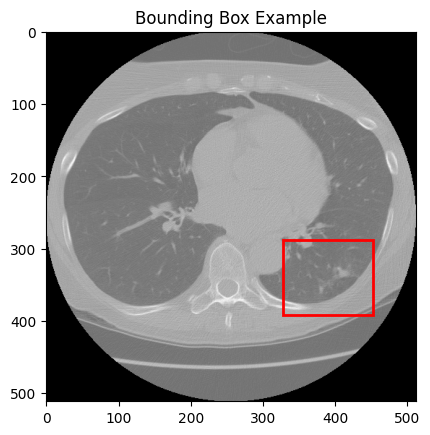

In [ ]:
# Plot the bounding box on the image

import matplotlib.patches as patches

# Create a figure and an axes object
fig, ax = plt.subplots()

# Plot the CT image
ax.imshow(img, cmap='gray')

xmin = df_sr_max_width['x0'].values[0]
ymin = df_sr_max_width['y0'].values[0]
width = df_sr_max_width['width'].values[0]
height = df_sr_max_width['height'].values[0]

print('xmin: ' + str(xmin))
print('ymin: ' + str(ymin))
print('width: ' + str(width))
print('height: ' + str(height))

# Create a Rectangle patch
# The first argument is the (x, y) coordinates of the lower-left corner
# The next two arguments are width and height
# edgecolor sets the color of the box outline
# facecolor sets the fill color (set to 'none' for no fill)
# linewidth sets the thickness of the outline
rect = patches.Rectangle((xmin, ymin), width, height,
                         edgecolor='red', facecolor='none', linewidth=2)


ax.add_patch(rect)
ax.set_title('Bounding Box Example')
plt.show()
